Ya teniendo la base elegida, hay que programar

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Como ya elegimos la base, lo ponemos en columan

In [15]:
df = pd.read_csv('/content/drive/MyDrive/Universidad/Tecnicatura UBA/Laboratorio/Laboratorio-de-metodos-Cuantitativos-Aplicados-a-la-gestion/DF/Dataset ej1 Integración 1.2.csv')

print("--- Primeras filas de la base ---")
print(df.head())

--- Primeras filas de la base ---
  Ticker                 Emisor  Ley Moneda de Pago  Precio   TIR  TNA SA  \
0  GYC4D             360 ENERGY  ARG            MEP    89.8  14.6    14.1   
1  GYC5D             360 ENERGY  ARG            MEP     NaN   NaN     NaN   
2  AERBD  AEROPUERTOS ARGENTINA  ARG            MEP   102.5   5.3     5.2   
3  LMS7D                  ALUAR  ARG            MEP   104.2  -0.9    -0.9   
4  LMS8D                  ALUAR  ARG            MEP   103.0   4.0     4.0   

   Modified Duration  Duration  Convexidad  Paridad  Current Yield  \
0                1.8       1.9         3.9     89.7            8.9   
1                NaN       NaN         NaN      NaN            NaN   
2                1.1       1.1         1.6    100.3            5.4   
3                1.5       1.5         3.4    112.4            6.2   
4                1.0       1.0         1.2    102.2            6.1   

  Calificación Próxima Fecha de Pago Fecha de Vencimiento  
0            A        

En esta parte, ahora tego que armar las matrices:
Cada fila con cada pedido, minimo, porsentaje, etc

In [16]:
print("\n--- Análisis Estadístico Descriptivo ---")
print(df.describe())

total_registros = len(df) #utilizo la funcion len para filtrar los datos
columnas = df.columns.tolist() #en cambio, este devuleve Index con los nombres de las columnas

print(f"\nCantidad de registros: {total_registros}")
print(f"Columnas disponibles: {columnas}")


--- Análisis Estadístico Descriptivo ---
           Precio         TIR      TNA SA  Modified Duration    Duration  \
count  113.000000  113.000000  113.000000         113.000000  113.000000   
mean    96.856637    6.440708    6.293805           2.418584    2.500885   
std     14.175450    4.595973    4.541324           1.778470    1.854459   
min     41.500000  -17.400000  -18.200000           0.000000    0.000000   
25%     99.100000    5.100000    5.000000           1.000000    1.000000   
50%    102.500000    6.600000    6.500000           1.800000    1.900000   
75%    104.200000    8.000000    7.800000           3.700000    3.800000   
max    110.300000   21.200000   20.200000           6.300000    6.500000   

       Convexidad     Paridad  Current Yield  
count  113.000000  113.000000     113.000000  
mean    11.954867   98.224779       6.643363  
std     15.064700    9.694702       1.652102  
min      0.000000   64.900000       0.900000  
25%      1.600000   98.900000       5.

Se necesita graficar

Text(0.5, 1.0, 'Distribución de Precio')

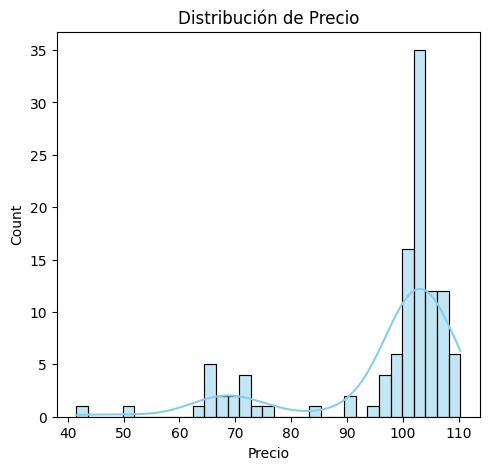

In [17]:
#grafico 1 que es la distribucion del precion
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

col_numerica = df.select_dtypes(include=['number']).columns[0]
sns.histplot(df[col_numerica], kde=True, color='skyblue')
plt.title(f'Distribución de {col_numerica}')


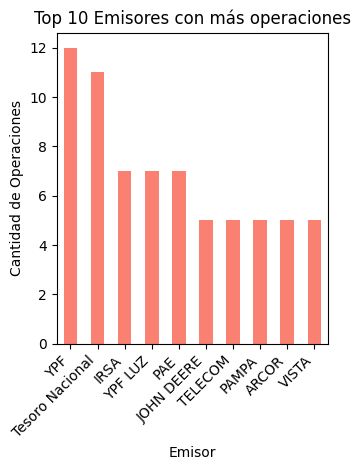

In [18]:
#el grafico 2, corregido por la IA, ya que en la vercion anterior marcaba todos los vendedores haciendo imposible la lectura de los datos.
plt.subplot(1, 2, 2)
top_vendedores = df['Emisor'].value_counts().head(10)
top_vendedores.plot(kind='bar', color='salmon')

plt.title('Top 10 Emisores con más operaciones')
plt.xlabel('Emisor')
plt.ylabel('Cantidad de Operaciones')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Ahora necesito un resumen de la base de datos

In [19]:
resumen_df = df.groupby(col_categorica)[col_numerica].agg(['mean', 'sum', 'count']).reset_index()

print("\n--- Nuevo DataFrame: Resumen de Métricas por Grupo ---")
print(resumen_df)


--- Nuevo DataFrame: Resumen de Métricas por Grupo ---
    Ticker   mean    sum  count
0     AE38   73.3   73.3      1
1    AERBD  102.5  102.5      1
2     AL29   66.4   66.4      1
3     AL30   63.6   63.6      1
4     AL35   71.3   71.3      1
..     ...    ...    ...    ...
119  YMCQD  102.4  102.4      1
120  YMCVD  102.0  102.0      1
121  YMCXD  106.7  106.7      1
122  YMCYD   99.2   99.2      1
123  ZZC1D  102.2  102.2      1

[124 rows x 4 columns]


Por ultimo, para entender mejor la base de datos elegido. se necesita una conclucion

In [20]:
max_categoria = resumen_df.loc[resumen_df['sum'].idxmax(), col_categorica]

print("\n--- Conclusiones Generales ---")
print(f"1. La base de datos cuenta con {total_registros} registros analizados.")
print(f"2. La categoría con mayor impacto (suma total) es: '{max_categoria}'.")
print(f"3. Se observa una concentración de datos en los niveles bajos/medios según el histograma.")


--- Conclusiones Generales ---
1. La base de datos cuenta con 124 registros analizados.
2. La categoría con mayor impacto (suma total) es: 'VSCVD'.
3. Se observa una concentración de datos en los niveles bajos/medios según el histograma.
